#  Projet Data Mining — Pipeline Complet
**Dataset :** Étude sur la solitude et le capital social (6708 individus, 25 variables)

## Plan
1. Chargement et exploration initiale
2. Prétraitement
   - (a) Valeurs sentinelles (-99)
   - (b) Doublons
   - (c) Valeurs manquantes
   - (d) Outliers (IQR + capping)
   - (e) Encodage des variables catégorielles
3. Normalisation et standardisation
4. Séparation Train / Test (70/30 et 80/20)
5. Réduction de dimension — ACP (PCA)
6. **Classification supervisée**
   - Régression Logistique
   - K-Nearest Neighbors
   - Decision Tree
   - Random Forest
   - SVM
   - Gradient Boosting
   - **GridSearchCV** (optimisation des hyperparamètres)
   - Comparaison des modèles
7. **Clustering non-supervisé**
   - K-Means (méthode du coude + silhouette)
   - DBSCAN
   - Clustering Hiérarchique
   - Comparaison et interprétation

---
## 1. Chargement et exploration initiale

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Librairies sklearn — prétraitement
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay,
                             roc_auc_score, roc_curve)

# Librairies sklearn — classification
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

# Librairies sklearn — clustering
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Paramètres globaux
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
RANDOM_STATE = 42

# Charger le dataset
df = pd.read_excel('dataset.xlsx')
print(f'Dimensions : {df.shape[0]} lignes × {df.shape[1]} colonnes')
df.head()

Dimensions : 6708 lignes × 25 colonnes


,ID,Gender,Age_Categories,Income,Marital_Status,Carer,Parent,UCLA_Single_Frequency,UCLA_Comp_Often,UCLA_Leftout_Often,...,When_Young,When_Young_Adult,When_Adult,When_Mid_Life,When_Older_Adult,UCLA3_tot,Other_times_count,UCLA3_gp,Marital_Stat3,SRH_gp
0,29,1,8,1.0,4,1.0,2.0,1,1.0,1.0,...,0,0,0,0,0,3.0,0.0,0.0,0.0,3.0
1,41,2,8,3.0,7,1.0,2.0,4,5.0,5.0,...,0,1,0,0,1,9.0,2.0,1.0,3.0,2.0
2,53,1,7,2.0,4,1.0,2.0,3,4.0,3.0,...,1,1,1,1,1,6.0,5.0,1.0,0.0,2.0
3,78,2,7,2.0,7,1.0,2.0,3,4.0,2.0,...,0,0,0,0,0,5.0,0.0,0.0,3.0,1.0
4,83,1,7,1.0,1,1.0,1.0,5,4.0,2.0,...,1,1,1,0,1,7.0,4.0,1.0,1.0,3.0


In [6]:
print('=== INFORMATIONS GÉNÉRALES ===')
df.info()
print('\n=== STATISTIQUES DESCRIPTIVES ===')
df.describe().round(2)

=== INFORMATIONS GÉNÉRALES ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6708 entries, 0 to 6707
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     6708 non-null   int64  
 1   Gender                 6708 non-null   int64  
 2   Age_Categories         6708 non-null   int64  
 3   Income                 6626 non-null   float64
 4   Marital_Status         6708 non-null   int64  
 5   Carer                  6570 non-null   float64
 6   Parent                 6575 non-null   float64
 7   UCLA_Single_Frequency  6708 non-null   int64  
 8   UCLA_Comp_Often        6459 non-null   float64
 9   UCLA_Leftout_Often     6427 non-null   float64
 10  UCLA_Isolated_Often    6382 non-null   float64
 11  Times_Alone            6360 non-null   float64
 12  Other_Times            6352 non-null   float64
 13  Health_Self_Rating     6708 non-null   int64  
 14  Social_Capital         53

,ID,Gender,Age_Categories,Income,Marital_Status,Carer,Parent,UCLA_Single_Frequency,UCLA_Comp_Often,UCLA_Leftout_Often,...,When_Young,When_Young_Adult,When_Adult,When_Mid_Life,When_Older_Adult,UCLA3_tot,Other_times_count,UCLA3_gp,Marital_Stat3,SRH_gp
count,6708.0,6708.00,6708.00,6626.00,6708.00,6570.00,6575.00,6708.00,6459.00,6427.00,...,6708.00,6708.00,6708.00,6708.00,6708.00,6314.00,6352.00,6314.00,6574.00,5428.00
mean,25173.1,1.71,7.17,2.32,2.91,1.08,1.72,-7.35,2.83,2.41,...,0.25,0.38,0.35,0.35,0.36,5.21,1.79,0.41,1.46,1.84
std,13854.8,1.32,0.38,0.66,14.68,0.27,0.45,30.53,1.35,1.28,...,0.43,0.48,0.48,0.48,0.48,2.21,1.62,0.49,1.17,0.82
min,29.0,-99.00,7.00,1.00,-99.00,1.00,1.00,-99.00,1.00,1.00,...,0.00,0.00,0.00,0.00,0.00,3.00,0.00,0.00,0.00,1.00
25%,14199.5,1.00,7.00,2.00,4.00,1.00,1.00,2.00,2.00,1.00,...,0.00,0.00,0.00,0.00,0.00,3.00,0.00,0.00,0.00,1.00
50%,27132.5,2.00,7.00,2.00,6.00,1.00,2.00,2.00,3.00,2.00,...,0.00,0.00,0.00,0.00,0.00,5.00,2.00,0.00,2.00,2.00
75%,35950.5,2.00,7.00,3.00,7.00,1.00,2.00,4.00,4.00,3.00,...,1.00,1.00,1.00,1.00,1.00,7.00,3.00,1.00,2.00,3.00
max,49199.0,4.00,8.00,3.00,8.00,2.00,2.00,5.00,5.00,5.00,...,1.00,1.00,1.00,1.00,1.00,9.00,5.00,1.00,3.00,3.00


In [5]:
ID_COL = 'ID'
CAT_COLS = ['Gender', 'Marital_Status', 'Carer', 'Parent',
            'When_Young', 'When_Young_Adult', 'When_Adult',
            'When_Mid_Life', 'When_Older_Adult',
            'UCLA3_gp', 'Marital_Stat3', 'SRH_gp']
NUM_COLS = [c for c in df.columns if c not in CAT_COLS + [ID_COL]]

print('Variables numériques continues :', NUM_COLS)
print('\nVariables catégorielles :', CAT_COLS)

Variables numériques continues : ['Age_Categories', 'Income', 'UCLA_Single_Frequency', 'UCLA_Comp_Often', 'UCLA_Leftout_Often', 'UCLA_Isolated_Often', 'Times_Alone', 'Other_Times', 'Health_Self_Rating', 'Social_Capital', 'UCLA3_tot', 'Other_times_count']

Variables catégorielles : ['Gender', 'Marital_Status', 'Carer', 'Parent', 'When_Young', 'When_Young_Adult', 'When_Adult', 'When_Mid_Life', 'When_Older_Adult', 'UCLA3_gp', 'Marital_Stat3', 'SRH_gp']


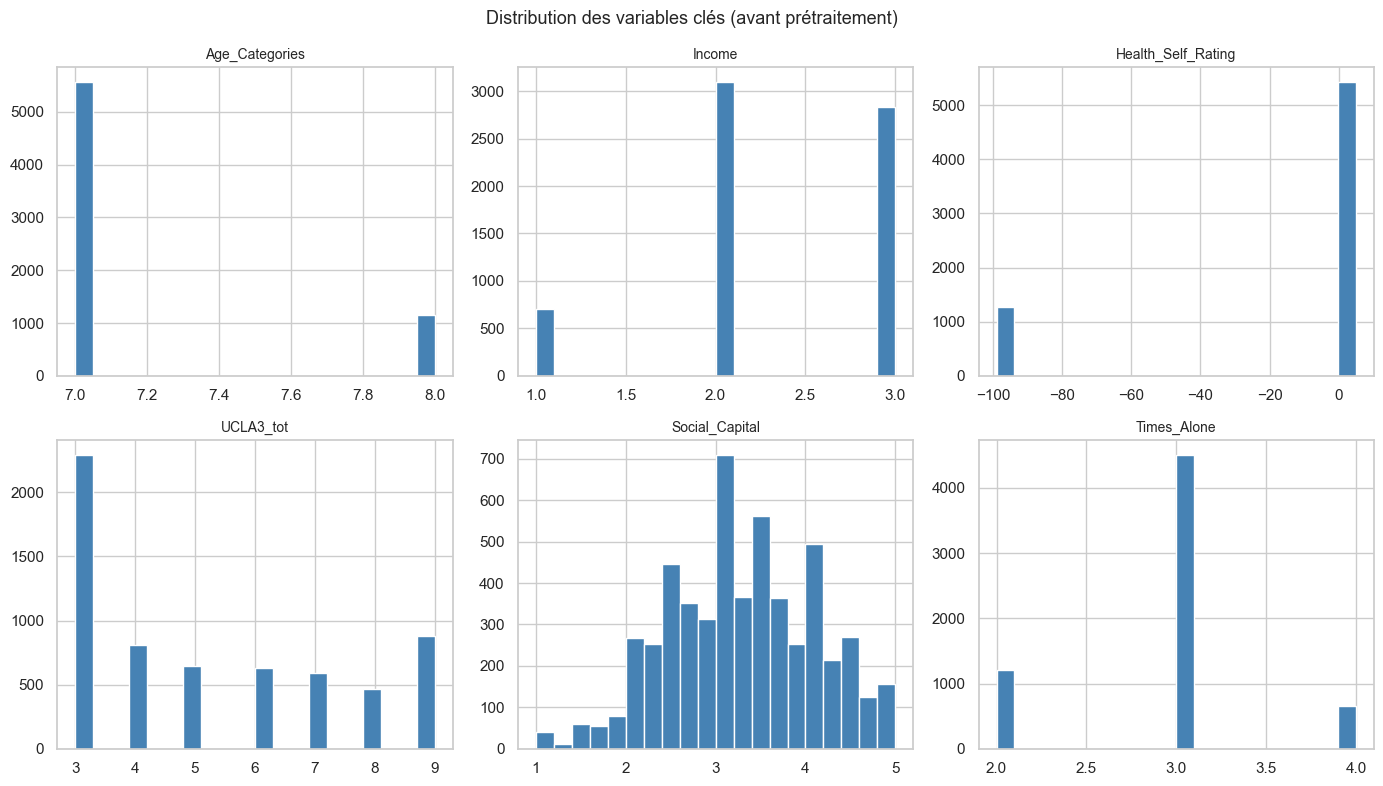

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
cols_to_plot = ['Age_Categories', 'Income', 'Health_Self_Rating',
                'UCLA3_tot', 'Social_Capital', 'Times_Alone']
for ax, col in zip(axes.flatten(), cols_to_plot):
    df[col].dropna().hist(ax=ax, bins=20, color='steelblue', edgecolor='white')
    ax.set_title(col, fontsize=10)
plt.suptitle('Distribution des variables clés (avant prétraitement)', fontsize=13)
plt.tight_layout()
plt.show()

---
## 2. Prétraitement
### (a) Valeurs sentinelles (-99)

In [8]:
sentinel_counts = (df == -99).sum()
print('Colonnes avec valeurs -99 :')
print(sentinel_counts[sentinel_counts > 0])
df.replace(-99, np.nan, inplace=True)
print(f'\nValeurs -99 restantes : {(df == -99).sum().sum()}')

Colonnes avec valeurs -99 :
Gender                      1
Marital_Status            134
UCLA_Single_Frequency     669
Health_Self_Rating       1280
dtype: int64

Valeurs -99 restantes : 0


### (b) Suppression des doublons

In [6]:
n_before = len(df)
df = df.drop_duplicates()
print(f'Doublons supprimés : {n_before - len(df)}')
print(f'Lignes restantes   : {len(df)}')

Doublons supprimés : 0
Lignes restantes   : 6708


### (c) Valeurs manquantes

Valeurs manquantes :
                       Manquants  Pourcentage (%)
Social_Capital              1310            19.53
Health_Self_Rating          1280            19.08
SRH_gp                      1280            19.08
UCLA_Single_Frequency        669             9.97
UCLA3_tot                    394             5.87
UCLA3_gp                     394             5.87
Other_Times                  356             5.31
Other_times_count            356             5.31
Times_Alone                  348             5.19
UCLA_Isolated_Often          326             4.86
UCLA_Leftout_Often           281             4.19
UCLA_Comp_Often              249             3.71
Carer                        138             2.06
Marital_Status               134             2.00
Marital_Stat3                134             2.00
Parent                       133             1.98
Income                        82             1.22
Gender                         1             0.01


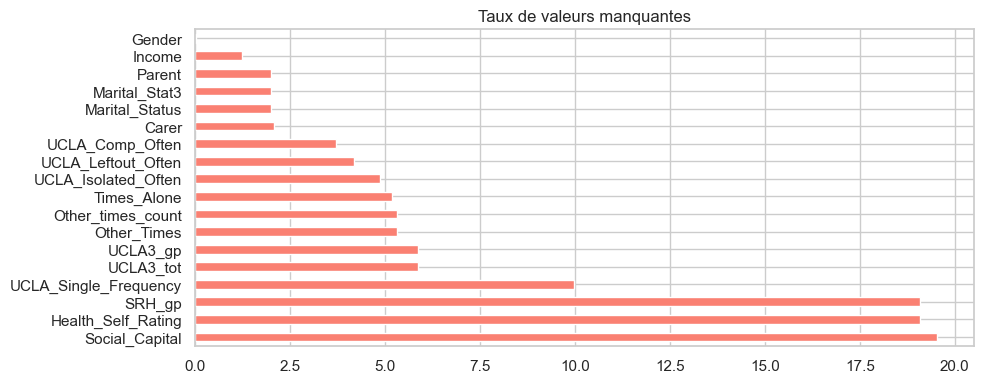

In [7]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Manquants': missing, 'Pourcentage (%)': missing_pct})
missing_df = missing_df[missing_df['Manquants'] > 0].sort_values('Pourcentage (%)', ascending=False)
print('Valeurs manquantes :')
print(missing_df)

if not missing_df.empty:
    fig, ax = plt.subplots(figsize=(10, 4))
    missing_df['Pourcentage (%)'].plot(kind='barh', ax=ax, color='salmon', edgecolor='white')
    ax.set_title('Taux de valeurs manquantes')
    plt.tight_layout()
    plt.show()

In [8]:
for col in NUM_COLS:
    if df[col].isnull().sum() > 0:
        med = df[col].median()
        df[col].fillna(med, inplace=True)
        print(f'  [{col}] → médiane = {med:.2f}')

for col in CAT_COLS:
    if df[col].isnull().sum() > 0:
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)
        print(f'  [{col}] → mode = {mode_val}')

print(f'\nValeurs manquantes restantes : {df.isnull().sum().sum()}')

  [Income] → médiane = 2.00
  [UCLA_Single_Frequency] → médiane = 3.00
  [UCLA_Comp_Often] → médiane = 3.00
  [UCLA_Leftout_Often] → médiane = 2.00
  [UCLA_Isolated_Often] → médiane = 2.00
  [Times_Alone] → médiane = 3.00
  [Other_Times] → médiane = 2.00
  [Health_Self_Rating] → médiane = 3.00
  [Social_Capital] → médiane = 3.29
  [UCLA3_tot] → médiane = 5.00
  [Other_times_count] → médiane = 2.00
  [Gender] → mode = 2.0
  [Marital_Status] → mode = 6.0
  [Carer] → mode = 1.0
  [Parent] → mode = 2.0
  [UCLA3_gp] → mode = 0.0
  [Marital_Stat3] → mode = 0.0
  [SRH_gp] → mode = 1.0

Valeurs manquantes restantes : 0


### (d) Outliers — Détection IQR + Capping

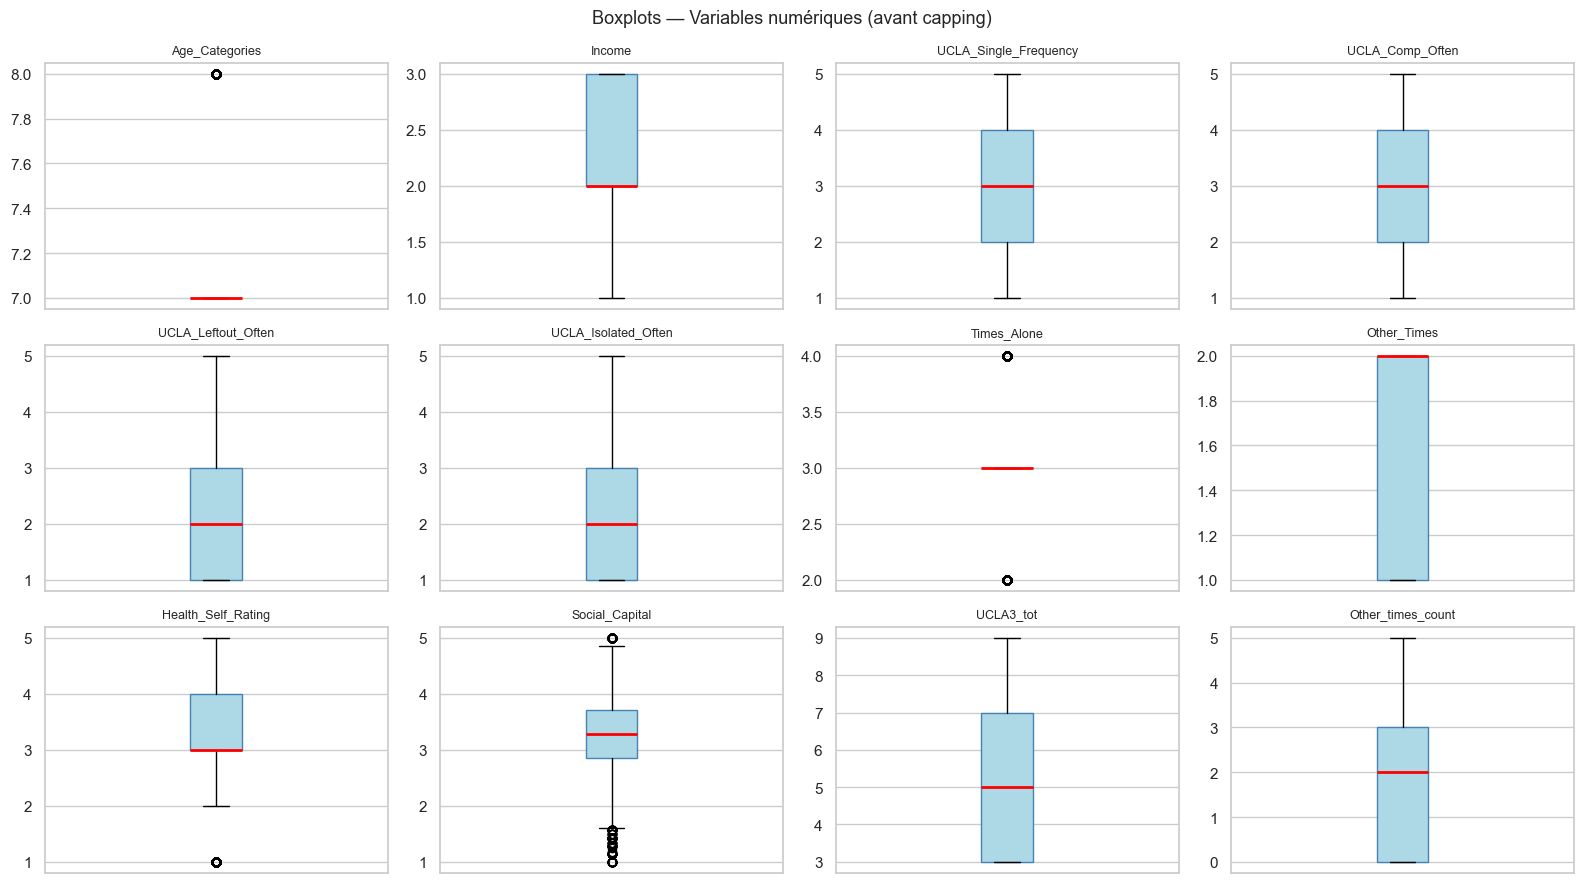

In [9]:
n_cols = 4
n_rows = int(np.ceil(len(NUM_COLS) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()
for i, col in enumerate(NUM_COLS):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='lightblue', color='steelblue'),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xticks([])
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Boxplots — Variables numériques (avant capping)', fontsize=13)
plt.tight_layout()
plt.show()

In [10]:
outlier_report = {}
for col in NUM_COLS:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out = ((df[col] < lo) | (df[col] > hi)).sum()
    outlier_report[col] = {'Borne inf.': round(lo,2), 'Borne sup.': round(hi,2),
                            'Outliers': n_out, 'Outliers (%)': round(n_out/len(df)*100, 2)}

outlier_df = pd.DataFrame(outlier_report).T
print(outlier_df[outlier_df['Outliers'] > 0].sort_values('Outliers (%)', ascending=False))

                    Borne inf.  Borne sup.  Outliers  Outliers (%)
Times_Alone               3.00         3.0    1856.0         27.67
Age_Categories            7.00         7.0    1144.0         17.05
Health_Self_Rating        1.50         5.5     378.0          5.64
Social_Capital            1.57         5.0     203.0          3.03


In [12]:
df_clean = df.copy()
for col in NUM_COLS:
    Q1, Q3 = df_clean[col].quantile(0.25), df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    df_clean[col] = df_clean[col].clip(Q1 - 1.5*IQR, Q3 + 1.5*IQR)
print(' Capping IQR appliqué sur toutes les variables numériques.')
print(f'Shape : {df_clean.shape}')

 Capping IQR appliqué sur toutes les variables numériques.
Shape : (6708, 25)


### (e) Encodage des variables catégorielles

In [14]:
df_encoded = df_clean.copy()
binary_cols = ['Carer','Parent','When_Young','When_Young_Adult','When_Adult','When_Mid_Life','When_Older_Adult']
ordinal_cols = ['Gender','Marital_Status','UCLA3_gp','Marital_Stat3','SRH_gp']

for col in binary_cols + ordinal_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(int))

print(' Encodage terminé.')
print(f'Shape : {df_encoded.shape}')

 Encodage terminé.
Shape : (6708, 25)


---
## 3. Normalisation Min-Max + Standardisation Z-score

In [15]:
df_ids = df_encoded[[ID_COL]].copy()
feature_cols = [c for c in df_encoded.columns if c != ID_COL]
df_features = df_encoded[feature_cols].copy()

scaler_minmax = MinMaxScaler()
df_features[NUM_COLS] = scaler_minmax.fit_transform(df_features[NUM_COLS])

print('Normalisation Min-Max appliquée.')
print(df_features[NUM_COLS].agg(['min','max']).round(4))

Normalisation Min-Max appliquée.
     Age_Categories  Income  UCLA_Single_Frequency  UCLA_Comp_Often  \
min             0.0     0.0                    0.0              0.0   
max             0.0     1.0                    1.0              1.0   

     UCLA_Leftout_Often  UCLA_Isolated_Often  Times_Alone  Other_Times  \
min                 0.0                  0.0          0.0          0.0   
max                 1.0                  1.0          0.0          1.0   

     Health_Self_Rating  Social_Capital  UCLA3_tot  Other_times_count  
min                 0.0             0.0        0.0                0.0  
max                 1.0             1.0        1.0                1.0  


---
## 4. Séparation Train / Test

On teste les deux ratios classiques : **70/30** et **80/20**.
La variable cible utilisée est `UCLA3_gp` (groupe de solitude — 3 classes).

In [16]:
# Définir X et y
TARGET = 'UCLA3_gp'
X = df_features.drop(columns=[TARGET]).values
y = df_features[TARGET].values
feature_names = [c for c in df_features.columns if c != TARGET]

print(f'X shape : {X.shape}')
print(f'y shape : {y.shape}')
print(f'Classes : {np.unique(y)}')
print(f'Distribution des classes :')
vals, counts = np.unique(y, return_counts=True)
for v, c in zip(vals, counts):
    print(f'  Classe {v} : {c} ({c/len(y)*100:.1f}%)')

X shape : (6708, 23)
y shape : (6708,)
Classes : [0 1]
Distribution des classes :
  Classe 0 : 4141 (61.7%)
  Classe 1 : 2567 (38.3%)


In [18]:
# ── Split 70 / 30 ──
X_train_70, X_test_30, y_train_70, y_test_30 = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y)

# ── Split 80 / 20 ──
X_train_80, X_test_20, y_train_80, y_test_20 = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)

print('=== SPLITS ===')
print(f'70/30 → Train : {X_train_70.shape[0]} | Test : {X_test_30.shape[0]}')
print(f'80/20 → Train : {X_train_80.shape[0]} | Test : {X_test_20.shape[0]}')
print('\n stratify=y → ratio des classes préservé dans chaque split')

=== SPLITS ===
70/30 → Train : 4695 | Test : 2013
80/20 → Train : 5366 | Test : 1342

 stratify=y → ratio des classes préservé dans chaque split


---
## 5. Réduction de dimension — PCA
On standardise (Z-score) avant la PCA. Le scaler est **fitté sur le train uniquement** → pas de data leakage.

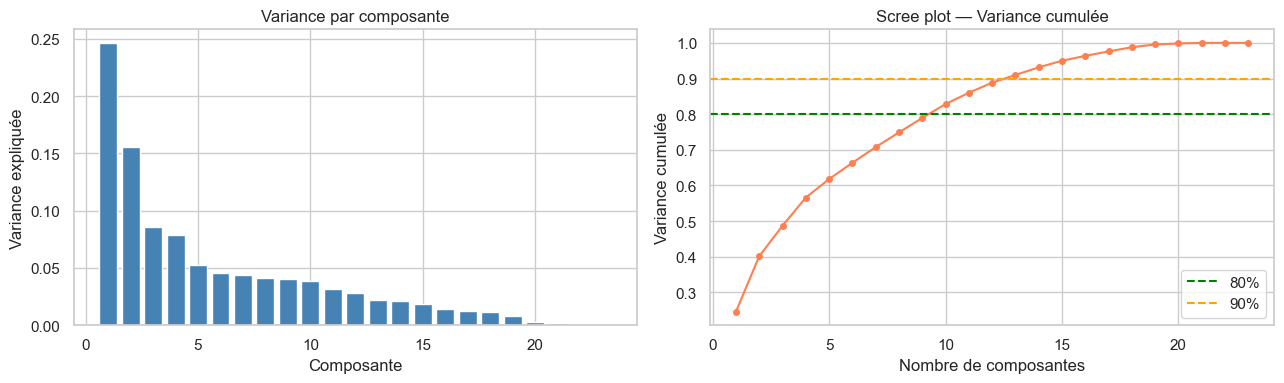

Composantes pour 80% de variance : 10
Composantes pour 90% de variance : 13


In [19]:
# On travaille avec le split 70/30 pour la suite
scaler_std = StandardScaler()
X_train_scaled = scaler_std.fit_transform(X_train_70)
X_test_scaled  = scaler_std.transform(X_test_30)

# PCA complète — analyse variance
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_train_scaled)
cumvar = pca_full.explained_variance_ratio_.cumsum()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(range(1, len(pca_full.explained_variance_ratio_)+1),
            pca_full.explained_variance_ratio_, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Composante')
axes[0].set_ylabel('Variance expliquée')
axes[0].set_title('Variance par composante')

axes[1].plot(range(1, len(cumvar)+1), cumvar, marker='o', markersize=4, color='coral')
axes[1].axhline(0.80, color='green', linestyle='--', label='80%')
axes[1].axhline(0.90, color='orange', linestyle='--', label='90%')
axes[1].set_xlabel('Nombre de composantes')
axes[1].set_ylabel('Variance cumulée')
axes[1].set_title('Scree plot — Variance cumulée')
axes[1].legend()
plt.tight_layout()
plt.show()

n_80 = (cumvar < 0.80).sum() + 1
n_90 = (cumvar < 0.90).sum() + 1
print(f'Composantes pour 80% de variance : {n_80}')
print(f'Composantes pour 90% de variance : {n_90}')

Dimensions train avant PCA : (4695, 23)
Dimensions train après PCA : (4695, 10)
Variance expliquée totale  : 0.8283


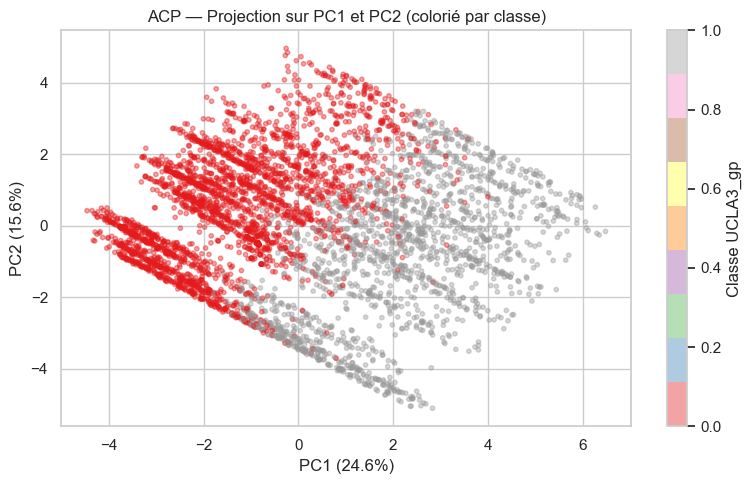

In [20]:
# PCA finale (80% variance)
pca = PCA(n_components=0.80, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

print(f'Dimensions train avant PCA : {X_train_scaled.shape}')
print(f'Dimensions train après PCA : {X_train_pca.shape}')
print(f'Variance expliquée totale  : {pca.explained_variance_ratio_.sum():.4f}')

# Projection PC1 vs PC2
plt.figure(figsize=(8, 5))
scatter = plt.scatter(X_train_pca[:,0], X_train_pca[:,1],
                      c=y_train_70, cmap='Set1', alpha=0.4, s=10)
plt.colorbar(scatter, label='Classe UCLA3_gp')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('ACP — Projection sur PC1 et PC2 (colorié par classe)')
plt.tight_layout()
plt.show()

---
## 6. Classification supervisée

On entraîne et compare plusieurs classifieurs sur les données **après PCA** (split 70/30).  
On utilise la **validation croisée 5-fold** pour l'évaluation, puis **GridSearchCV** pour l'optimisation.

In [ ]:

# Données de travail pour la classification
Xc_train, Xc_test = X_train_pca, X_test_pca
yc_train, yc_test = y_train_70, y_test_30

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, cv_obj):
    """Entraîne, évalue et retourne les métriques d'un modèle."""
    # Cross-validation
    cv_scores = cross_val_score(model, X_tr, y_tr, cv=cv_obj, scoring='accuracy')
    # Fit + predict
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    acc_test = accuracy_score(y_te, y_pred)
    # AUC (si proba disponible)
    auc = None
    if hasattr(model, 'predict_proba'):
        try:
            y_proba = model.predict_proba(X_te)
            n_classes = len(np.unique(y_te))
            if n_classes == 2:
                # Pour la classification binaire, j'utilise les probas de la classe positive
                auc = roc_auc_score(y_te, y_proba[:, 1])
            else:
                # Pour la multi-classe, j'utilise ovr avec macro average
                auc = roc_auc_score(y_te, y_proba, multi_class='ovr', average='macro', labels=np.unique(y_te))
        except Exception as e:
            auc = None
    return {
        'Modèle': name,
        'CV Accuracy (mean)': round(cv_scores.mean(), 4),
        'CV Std': round(cv_scores.std(), 4),
        'Test Accuracy': round(acc_test, 4),
        'AUC-ROC (macro)': round(auc, 4) if auc else 'N/A'
    }

print(' Fonctions utilitaires définies.')



 Fonctions utilitaires définies.


In [30]:
results = []

# ── 1. Régression Logistique ──
lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
results.append(evaluate_model('Logistic Regression', lr, Xc_train, yc_train, Xc_test, yc_test, cv))

# ── 2. K-Nearest Neighbors ──
knn = KNeighborsClassifier(n_neighbors=5)
results.append(evaluate_model('KNN (k=5)', knn, Xc_train, yc_train, Xc_test, yc_test, cv))

# ── 3. Decision Tree ──
dt = DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)
results.append(evaluate_model('Decision Tree', dt, Xc_train, yc_train, Xc_test, yc_test, cv))

# ── 4. Random Forest ──
rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
results.append(evaluate_model('Random Forest', rf, Xc_train, yc_train, Xc_test, yc_test, cv))

# ── 5. SVM ──
svm = SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE)
results.append(evaluate_model('SVM (RBF)', svm, Xc_train, yc_train, Xc_test, yc_test, cv))

# ── 6. Gradient Boosting ──
gb = GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE)
results.append(evaluate_model('Gradient Boosting', gb, Xc_train, yc_train, Xc_test, yc_test, cv))

results_df = pd.DataFrame(results)
print('=== RÉSULTATS COMPARATIFS ===')
print(results_df.to_string(index=False))

=== RÉSULTATS COMPARATIFS ===
             Modèle  CV Accuracy (mean)  CV Std  Test Accuracy  AUC-ROC (macro)
Logistic Regression              0.9619  0.0102         0.9707           0.9941
          KNN (k=5)              0.9365  0.0094         0.9349           0.9835
      Decision Tree              0.9242  0.0065         0.9354           0.9741
      Random Forest              0.9512  0.0063         0.9593           0.9920
          SVM (RBF)              0.9597  0.0045         0.9677           0.9931
  Gradient Boosting              0.9548  0.0088         0.9608           0.9915


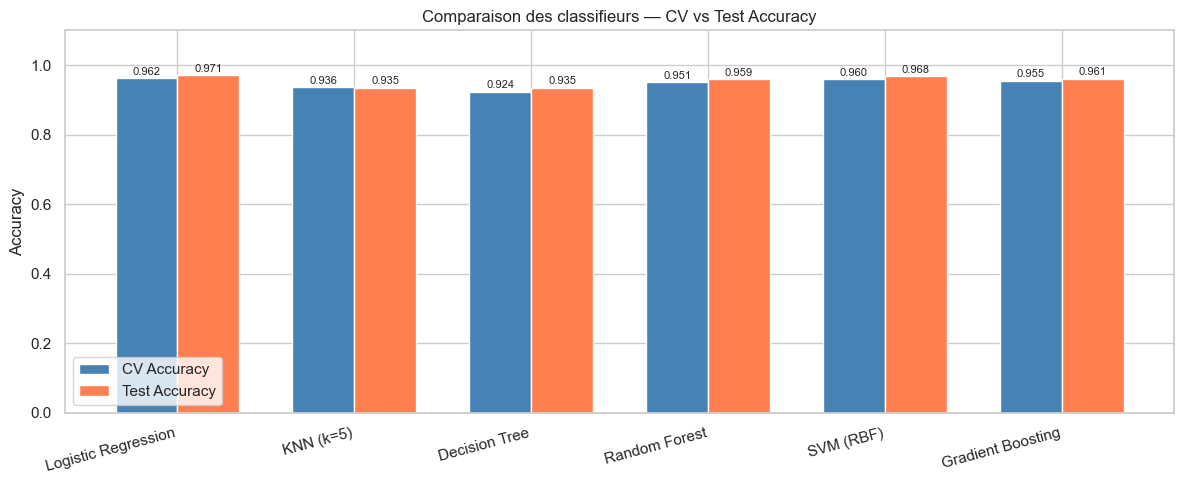

In [31]:
# Visualisation comparative
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(results_df))
w = 0.35
bars1 = ax.bar(x - w/2, results_df['CV Accuracy (mean)'], w, label='CV Accuracy', color='steelblue', edgecolor='white')
bars2 = ax.bar(x + w/2, results_df['Test Accuracy'], w, label='Test Accuracy', color='coral', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(results_df['Modèle'], rotation=15, ha='right')
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1.1)
ax.set_title('Comparaison des classifieurs — CV vs Test Accuracy')
ax.legend()
for bar in bars1: ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f'{bar.get_height():.3f}', ha='center', fontsize=8)
for bar in bars2: ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f'{bar.get_height():.3f}', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

### 6.1 Matrice de confusion — Meilleur modèle
On sélectionne automatiquement le meilleur modèle selon la Test Accuracy.

Meilleur modèle : Logistic Regression

=== RAPPORT DE CLASSIFICATION ===
              precision    recall  f1-score   support

           0       0.97      0.98      0.98      1243
           1       0.96      0.96      0.96       770

    accuracy                           0.97      2013
   macro avg       0.97      0.97      0.97      2013
weighted avg       0.97      0.97      0.97      2013



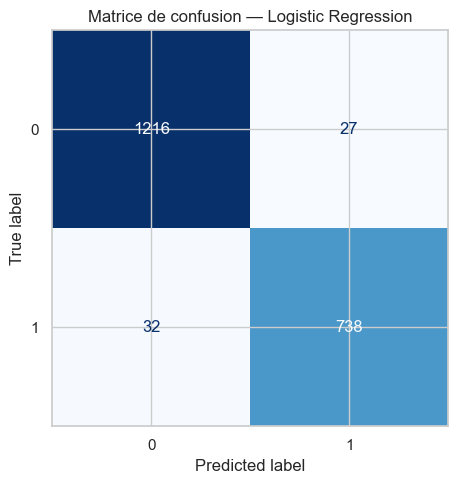

In [32]:
best_name = results_df.loc[results_df['Test Accuracy'].idxmax(), 'Modèle']
print(f'Meilleur modèle : {best_name}')

# Re-fit le meilleur modèle
best_models = {
    'Logistic Regression': lr, 'KNN (k=5)': knn,
    'Decision Tree': dt, 'Random Forest': rf,
    'SVM (RBF)': svm, 'Gradient Boosting': gb
}
best_clf = best_models[best_name]
best_clf.fit(Xc_train, yc_train)
y_pred_best = best_clf.predict(Xc_test)

# Rapport de classification
print('\n=== RAPPORT DE CLASSIFICATION ===')
print(classification_report(yc_test, y_pred_best))

# Matrice de confusion
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(yc_test, y_pred_best)
disp = ConfusionMatrixDisplay(cm)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Matrice de confusion — {best_name}')
plt.tight_layout()
plt.show()

---
## 7. GridSearchCV — Optimisation des hyperparamètres

On applique **GridSearchCV** avec validation croisée 5-fold sur **3 modèles** : KNN, Decision Tree et Random Forest.

In [35]:
# ── GridSearchCV — KNN ──
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}
gs_knn = GridSearchCV(
    KNeighborsClassifier(), param_grid_knn,
    cv=cv, scoring='accuracy', n_jobs=-1, verbose=0
)
gs_knn.fit(Xc_train, yc_train)
print(' KNN terminé')
print(f'   Meilleurs params  : {gs_knn.best_params_}')
print(f'   Best CV accuracy  : {gs_knn.best_score_:.4f}')
print(f'   Test accuracy     : {accuracy_score(yc_test, gs_knn.predict(Xc_test)):.4f}')
print()

 KNN terminé
   Meilleurs params  : {'metric': 'euclidean', 'n_neighbors': 11, 'weights': 'uniform'}
   Best CV accuracy  : 0.9404
   Test accuracy     : 0.9503



In [37]:
# ── GridSearchCV — Decision Tree ──
param_grid_dt = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}
gs_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE), param_grid_dt,
    cv=cv, scoring='accuracy', n_jobs=-1, verbose=0
)
gs_dt.fit(Xc_train, yc_train)
print(' Decision Tree terminé')
print(f'   Meilleurs params  : {gs_dt.best_params_}')
print(f'   Best CV accuracy  : {gs_dt.best_score_:.4f}')
print(f'   Test accuracy     : {accuracy_score(yc_test, gs_dt.predict(Xc_test)):.4f}')
print()

 Decision Tree terminé
   Meilleurs params  : {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 10}
   Best CV accuracy  : 0.9387
   Test accuracy     : 0.9394



In [39]:
# ── GridSearchCV — Random Forest ──
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 'log2']
}
gs_rf = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE), param_grid_rf,
    cv=cv, scoring='accuracy', n_jobs=-1, verbose=0
)
gs_rf.fit(Xc_train, yc_train)
print(' Random Forest terminé')
print(f'   Meilleurs params  : {gs_rf.best_params_}')
print(f'   Best CV accuracy  : {gs_rf.best_score_:.4f}')
print(f'   Test accuracy     : {accuracy_score(yc_test, gs_rf.predict(Xc_test)):.4f}')

 Random Forest terminé
   Meilleurs params  : {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 200}
   Best CV accuracy  : 0.9517
   Test accuracy     : 0.9622


In [40]:
# Tableau récapitulatif GridSearchCV
gs_results = pd.DataFrame([
    {'Modèle': 'KNN (GridSearch)',           'Best CV Accuracy': round(gs_knn.best_score_, 4),
     'Test Accuracy': round(accuracy_score(yc_test, gs_knn.predict(Xc_test)), 4),
     'Meilleurs paramètres': str(gs_knn.best_params_)},
    {'Modèle': 'Decision Tree (GridSearch)',  'Best CV Accuracy': round(gs_dt.best_score_, 4),
     'Test Accuracy': round(accuracy_score(yc_test, gs_dt.predict(Xc_test)), 4),
     'Meilleurs paramètres': str(gs_dt.best_params_)},
    {'Modèle': 'Random Forest (GridSearch)', 'Best CV Accuracy': round(gs_rf.best_score_, 4),
     'Test Accuracy': round(accuracy_score(yc_test, gs_rf.predict(Xc_test)), 4),
     'Meilleurs paramètres': str(gs_rf.best_params_)},
])
print('=== RÉSULTATS GRIDSEARCHCV ===')
print(gs_results.to_string(index=False))

=== RÉSULTATS GRIDSEARCHCV ===
                    Modèle  Best CV Accuracy  Test Accuracy                                                                      Meilleurs paramètres
          KNN (GridSearch)            0.9404         0.9503                          {'metric': 'euclidean', 'n_neighbors': 11, 'weights': 'uniform'}
Decision Tree (GridSearch)            0.9387         0.9394 {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 10}
Random Forest (GridSearch)            0.9517         0.9622  {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 200}


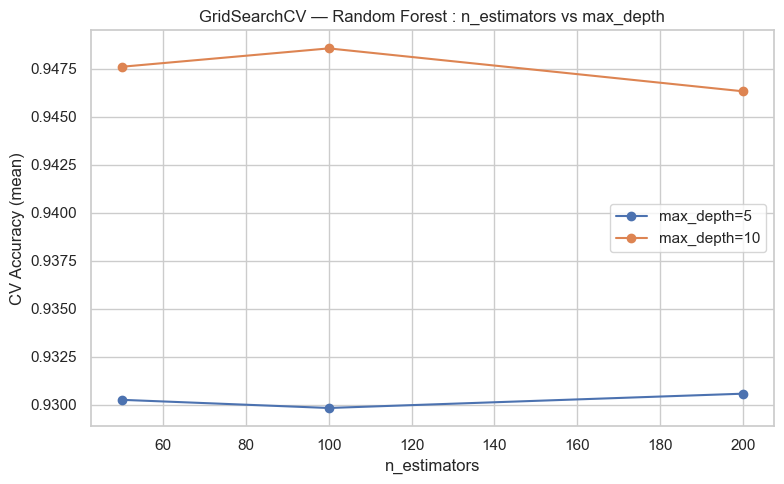

In [41]:
# Visualisation des courbes CV — Random Forest (exemple)
rf_cv_results = pd.DataFrame(gs_rf.cv_results_)
pivot = rf_cv_results.pivot_table(
    values='mean_test_score',
    index='param_n_estimators',
    columns='param_max_depth'
)

fig, ax = plt.subplots(figsize=(8, 5))
for col in pivot.columns:
    ax.plot(pivot.index, pivot[col], marker='o', label=f'max_depth={col}')
ax.set_xlabel('n_estimators')
ax.set_ylabel('CV Accuracy (mean)')
ax.set_title('GridSearchCV — Random Forest : n_estimators vs max_depth')
ax.legend()
plt.tight_layout()
plt.show()

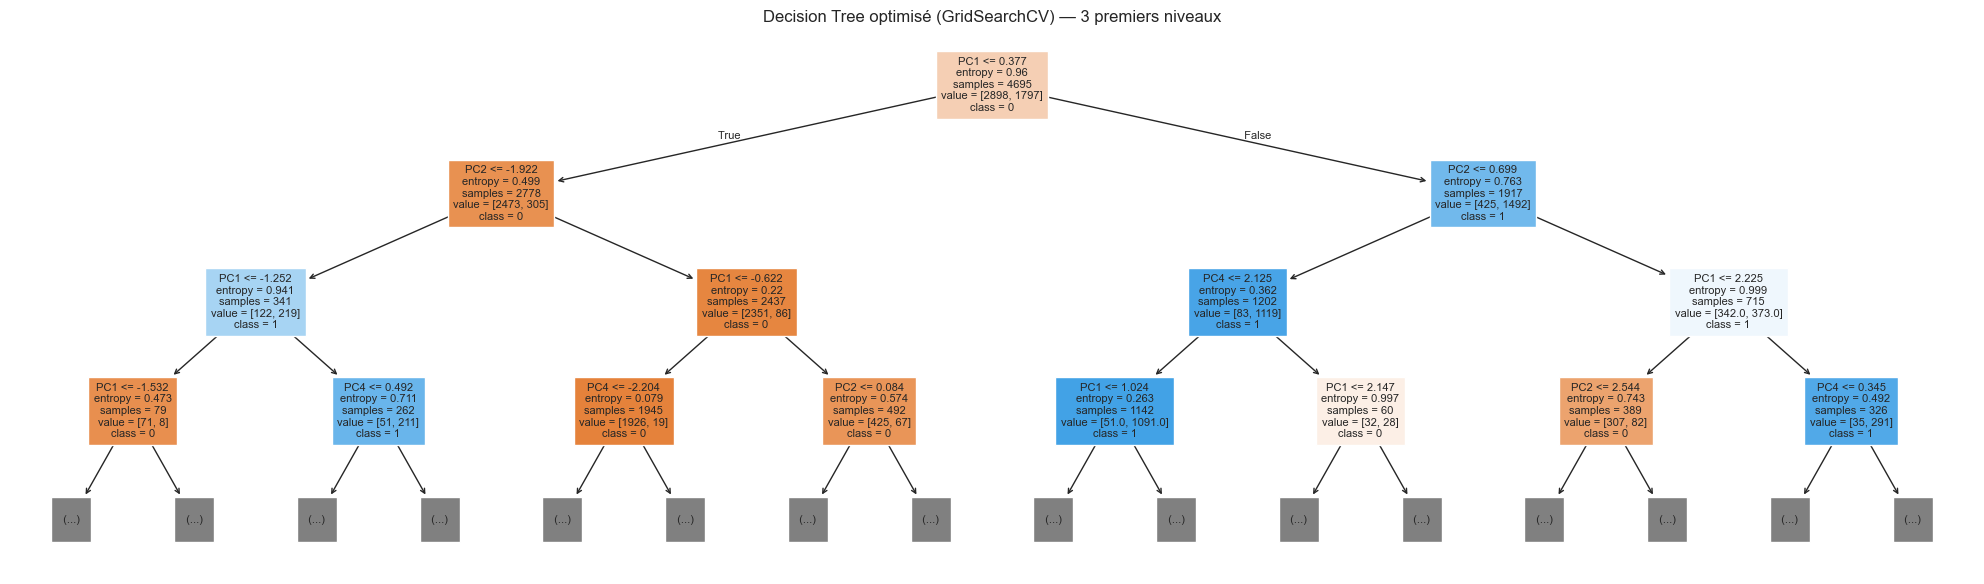

In [42]:
# Decision Tree optimisé — visualisation
fig, ax = plt.subplots(figsize=(20, 6))
plot_tree(gs_dt.best_estimator_, max_depth=3, filled=True, ax=ax,
          feature_names=[f'PC{i+1}' for i in range(Xc_train.shape[1])],
          class_names=[str(c) for c in np.unique(yc_train)],
          fontsize=8)
ax.set_title('Decision Tree optimisé (GridSearchCV) — 3 premiers niveaux')
plt.tight_layout()
plt.show()

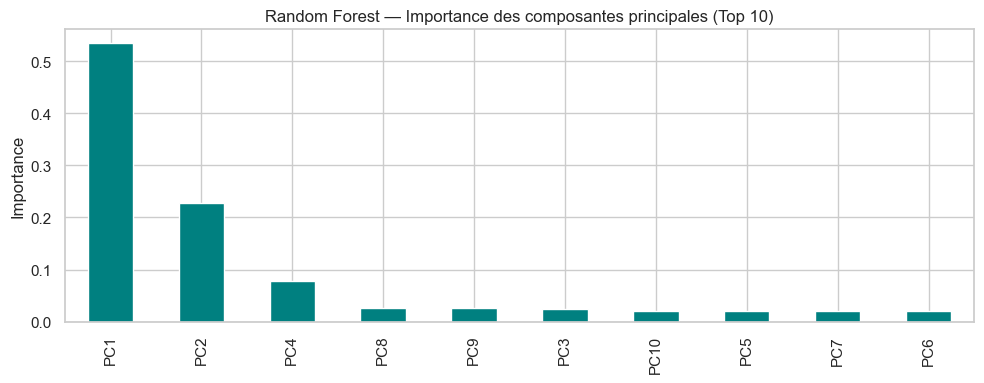

In [43]:
# Random Forest optimisé — feature importance
importances = pd.Series(
    gs_rf.best_estimator_.feature_importances_,
    index=[f'PC{i+1}' for i in range(Xc_train.shape[1])]
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
importances.head(10).plot(kind='bar', ax=ax, color='teal', edgecolor='white')
ax.set_title('Random Forest — Importance des composantes principales (Top 10)')
ax.set_ylabel('Importance')
plt.tight_layout()
plt.show()

---
## 8. Clustering non-supervisé

Le clustering est appliqué sur les données **standardisées après PCA** (sans étiquettes).  
On compare trois algorithmes : **K-Means**, **DBSCAN**, **Clustering Hiérarchique**.

In [44]:
# Données pour le clustering : train + test réunis (non supervisé)
X_cluster = np.vstack([X_train_pca, X_test_pca])
print(f'Données clustering : {X_cluster.shape}')

Données clustering : (6708, 10)


### 8.1 K-Means — Méthode du coude + Silhouette

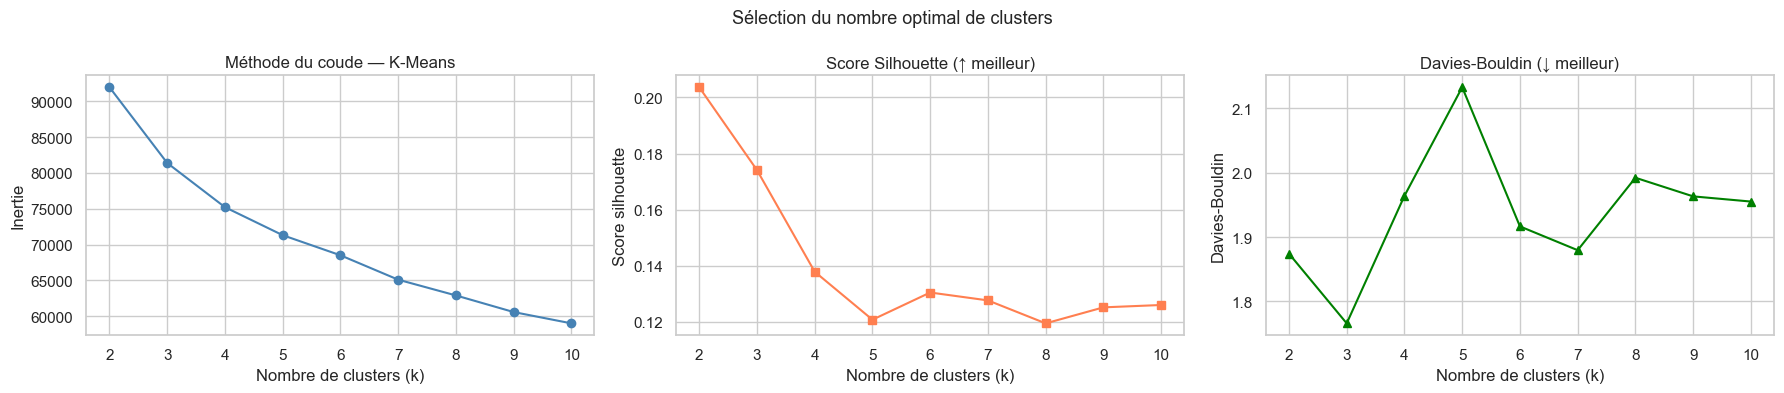

 k optimal selon silhouette : k = 2


In [46]:
inertias, silhouettes, db_scores = [], [], []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_cluster)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_cluster, labels))
    db_scores.append(davies_bouldin_score(X_cluster, labels))

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(K_range, inertias, marker='o', color='steelblue')
axes[0].set_xlabel('Nombre de clusters (k)')
axes[0].set_ylabel('Inertie')
axes[0].set_title('Méthode du coude — K-Means')

axes[1].plot(K_range, silhouettes, marker='s', color='coral')
axes[1].set_xlabel('Nombre de clusters (k)')
axes[1].set_ylabel('Score silhouette')
axes[1].set_title('Score Silhouette (↑ meilleur)')

axes[2].plot(K_range, db_scores, marker='^', color='green')
axes[2].set_xlabel('Nombre de clusters (k)')
axes[2].set_ylabel('Davies-Bouldin')
axes[2].set_title('Davies-Bouldin (↓ meilleur)')

plt.suptitle('Sélection du nombre optimal de clusters', fontsize=13)
plt.tight_layout()
plt.show()

best_k = K_range[silhouettes.index(max(silhouettes))]
print(f' k optimal selon silhouette : k = {best_k}')

K-Means (k=2) :
  Silhouette     : 0.2036
  Davies-Bouldin : 1.8742
  Calinski-Harab.: 1793.2041
  Distribution   :
    Cluster 0 : 3952 (58.9%)
    Cluster 1 : 2756 (41.1%)


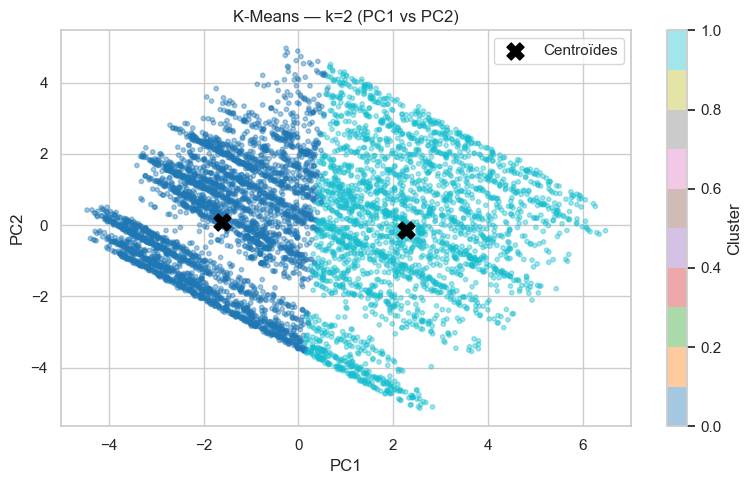

In [47]:
# K-Means final avec k optimal
km_best = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
km_labels = km_best.fit_predict(X_cluster)

print(f'K-Means (k={best_k}) :')
print(f'  Silhouette     : {silhouette_score(X_cluster, km_labels):.4f}')
print(f'  Davies-Bouldin : {davies_bouldin_score(X_cluster, km_labels):.4f}')
print(f'  Calinski-Harab.: {calinski_harabasz_score(X_cluster, km_labels):.4f}')
print(f'  Distribution   :')
for c, n in zip(*np.unique(km_labels, return_counts=True)):
    print(f'    Cluster {c} : {n} ({n/len(km_labels)*100:.1f}%)')

# Visualisation PC1 vs PC2
fig, ax = plt.subplots(figsize=(8, 5))
scatter = ax.scatter(X_cluster[:,0], X_cluster[:,1], c=km_labels,
                     cmap='tab10', alpha=0.4, s=10)
centers = km_best.cluster_centers_
ax.scatter(centers[:,0], centers[:,1], c='black', marker='X', s=150,
           zorder=5, label='Centroïdes')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title(f'K-Means — k={best_k} (PC1 vs PC2)')
ax.legend()
plt.colorbar(scatter, ax=ax, label='Cluster')
plt.tight_layout()
plt.show()

### 8.2 DBSCAN

In [48]:
# Recherche des meilleurs paramètres DBSCAN
dbscan_results = []
for eps in [0.3, 0.5, 0.7, 1.0, 1.5]:
    for min_s in [5, 10, 20]:
        db = DBSCAN(eps=eps, min_samples=min_s)
        labels = db.fit_predict(X_cluster)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = (labels == -1).sum()
        if n_clusters >= 2:
            sil = silhouette_score(X_cluster[labels != -1], labels[labels != -1])
        else:
            sil = -1
        dbscan_results.append({'eps': eps, 'min_samples': min_s,
                                'n_clusters': n_clusters, 'n_noise': n_noise,
                                'silhouette': round(sil, 4)})

dbscan_df = pd.DataFrame(dbscan_results).sort_values('silhouette', ascending=False)
print('=== DBSCAN — Exploration des paramètres ===')
print(dbscan_df.head(10).to_string(index=False))

=== DBSCAN — Exploration des paramètres ===
 eps  min_samples  n_clusters  n_noise  silhouette
 0.3           10           3     6601      1.0000
 0.3           20           2     6613      1.0000
 0.5           20           2     6612      0.9965
 0.7           20           2     6612      0.9965
 0.3            5          18     6504      0.9604
 0.5           10          11     6508      0.8875
 0.7           10          13     6455      0.7631
 0.5            5          45     6264      0.7021
 1.0           20           6     6393      0.5404
 0.7            5          78     5879      0.5025


Meilleur DBSCAN : eps=0.3, min_samples=10
  Clusters trouvés : 3
  Points bruit     : 6601 (98.4%)


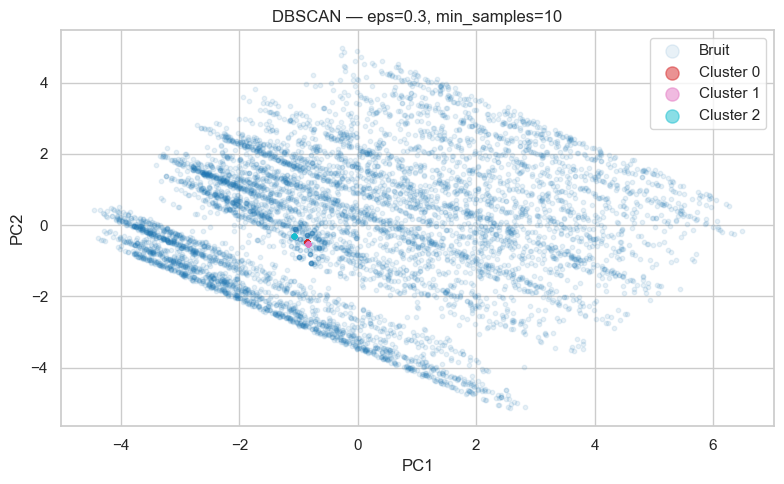

In [49]:
# Meilleur DBSCAN
best_dbscan = dbscan_df.iloc[0]
db_best = DBSCAN(eps=best_dbscan['eps'], min_samples=int(best_dbscan['min_samples']))
db_labels = db_best.fit_predict(X_cluster)
n_clust = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = (db_labels == -1).sum()

print(f'Meilleur DBSCAN : eps={best_dbscan["eps"]}, min_samples={int(best_dbscan["min_samples"])}')
print(f'  Clusters trouvés : {n_clust}')
print(f'  Points bruit     : {n_noise} ({n_noise/len(db_labels)*100:.1f}%)')

fig, ax = plt.subplots(figsize=(8, 5))
unique_labels = set(db_labels)
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))
for lbl, col in zip(sorted(unique_labels), colors):
    mask = db_labels == lbl
    label_name = f'Bruit' if lbl == -1 else f'Cluster {lbl}'
    ax.scatter(X_cluster[mask, 0], X_cluster[mask, 1],
               c=[col], alpha=0.5 if lbl != -1 else 0.1,
               s=10, label=label_name)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title(f'DBSCAN — eps={best_dbscan["eps"]}, min_samples={int(best_dbscan["min_samples"])}')
ax.legend(markerscale=3)
plt.tight_layout()
plt.show()

### 8.3 Clustering Hiérarchique (Agglomeratif)

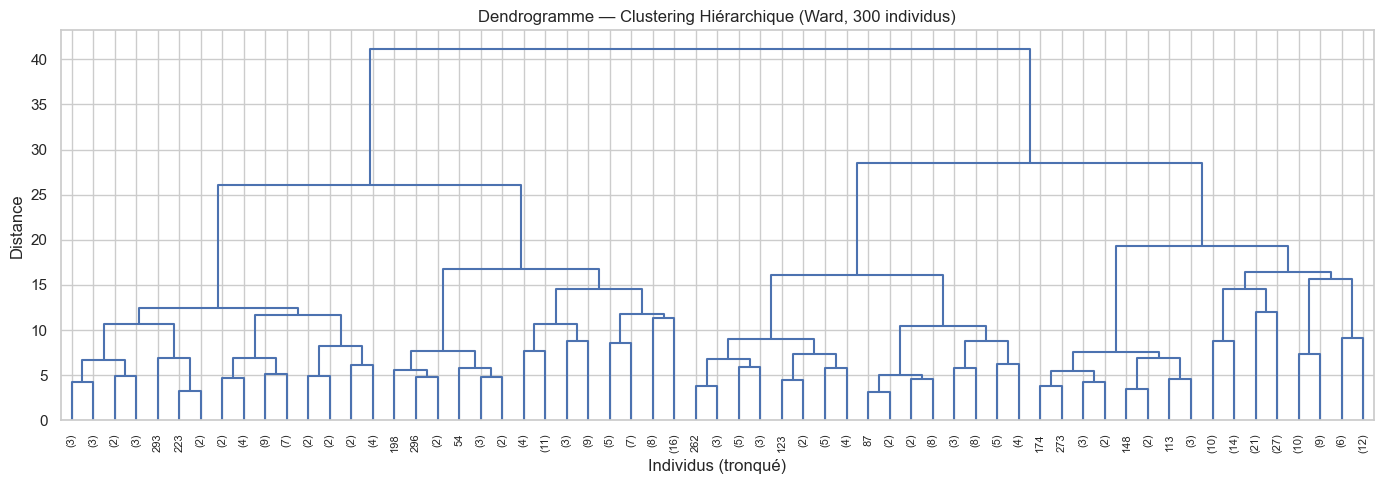

In [50]:
from scipy.cluster.hierarchy import dendrogram, linkage

# Dendrogramme (sur un échantillon pour lisibilité)
sample_idx = np.random.choice(len(X_cluster), size=300, replace=False)
X_sample = X_cluster[sample_idx]

Z = linkage(X_sample, method='ward')
fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(Z, ax=ax, truncate_mode='level', p=5,
           leaf_rotation=90, leaf_font_size=8, color_threshold=0)
ax.set_title('Dendrogramme — Clustering Hiérarchique (Ward, 300 individus)')
ax.set_xlabel('Individus (tronqué)')
ax.set_ylabel('Distance')
plt.tight_layout()
plt.show()

Clustering Hiérarchique (n_clusters=2, linkage=ward) :
  Silhouette     : 0.1322
  Davies-Bouldin : 2.4054
  Distribution   :
    Cluster 0 : 2549 (38.0%)
    Cluster 1 : 4159 (62.0%)


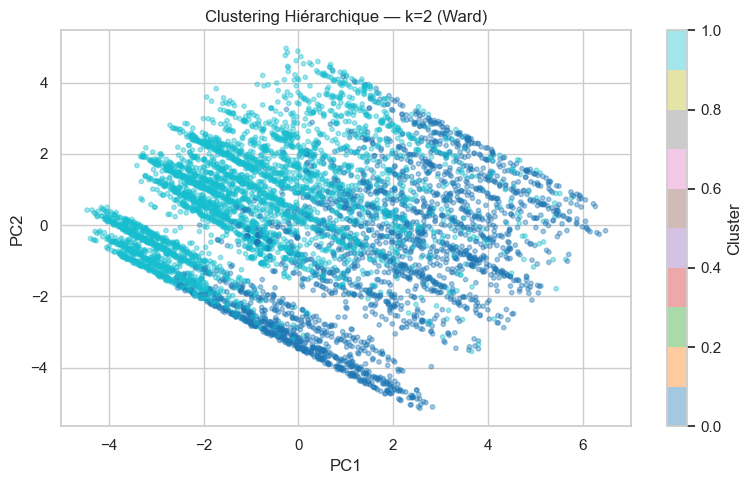

In [51]:
# Clustering hiérarchique avec le même k optimal que K-Means
hc = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
hc_labels = hc.fit_predict(X_cluster)

print(f'Clustering Hiérarchique (n_clusters={best_k}, linkage=ward) :')
print(f'  Silhouette     : {silhouette_score(X_cluster, hc_labels):.4f}')
print(f'  Davies-Bouldin : {davies_bouldin_score(X_cluster, hc_labels):.4f}')
print(f'  Distribution   :')
for c, n in zip(*np.unique(hc_labels, return_counts=True)):
    print(f'    Cluster {c} : {n} ({n/len(hc_labels)*100:.1f}%)')

fig, ax = plt.subplots(figsize=(8, 5))
scatter = ax.scatter(X_cluster[:,0], X_cluster[:,1], c=hc_labels,
                     cmap='tab10', alpha=0.4, s=10)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title(f'Clustering Hiérarchique — k={best_k} (Ward)')
plt.colorbar(scatter, ax=ax, label='Cluster')
plt.tight_layout()
plt.show()

### 8.4 Comparaison finale des méthodes de clustering

In [52]:
# Calcul des métriques DBSCAN (sur points non-bruit)
valid_mask = db_labels != -1
if valid_mask.sum() > 1 and len(set(db_labels[valid_mask])) >= 2:
    db_sil = silhouette_score(X_cluster[valid_mask], db_labels[valid_mask])
    db_dbi = davies_bouldin_score(X_cluster[valid_mask], db_labels[valid_mask])
    db_chi = calinski_harabasz_score(X_cluster[valid_mask], db_labels[valid_mask])
else:
    db_sil, db_dbi, db_chi = float('nan'), float('nan'), float('nan')

comparison = pd.DataFrame([
    {'Algorithme': f'K-Means (k={best_k})',
     'Silhouette (↑)': round(silhouette_score(X_cluster, km_labels), 4),
     'Davies-Bouldin (↓)': round(davies_bouldin_score(X_cluster, km_labels), 4),
     'Calinski-Harabasz (↑)': round(calinski_harabasz_score(X_cluster, km_labels), 2),
     'N clusters': best_k, 'N bruit': 0},
    {'Algorithme': f'DBSCAN (eps={best_dbscan["eps"]})',
     'Silhouette (↑)': round(db_sil, 4),
     'Davies-Bouldin (↓)': round(db_dbi, 4),
     'Calinski-Harabasz (↑)': round(db_chi, 2),
     'N clusters': n_clust, 'N bruit': int(n_noise)},
    {'Algorithme': f'Hiérarchique Ward (k={best_k})',
     'Silhouette (↑)': round(silhouette_score(X_cluster, hc_labels), 4),
     'Davies-Bouldin (↓)': round(davies_bouldin_score(X_cluster, hc_labels), 4),
     'Calinski-Harabasz (↑)': round(calinski_harabasz_score(X_cluster, hc_labels), 2),
     'N clusters': best_k, 'N bruit': 0},
])
print('=== COMPARAISON DES MÉTHODES DE CLUSTERING ===')
print(comparison.to_string(index=False))

=== COMPARAISON DES MÉTHODES DE CLUSTERING ===
             Algorithme  Silhouette (↑)  Davies-Bouldin (↓)  Calinski-Harabasz (↑)  N clusters  N bruit
          K-Means (k=2)          0.2036              1.8742           1.793200e+03           2        0
       DBSCAN (eps=0.3)          1.0000              0.0000           1.680315e+31           3     6601
Hiérarchique Ward (k=2)          0.1322              2.4054           1.041870e+03           2        0


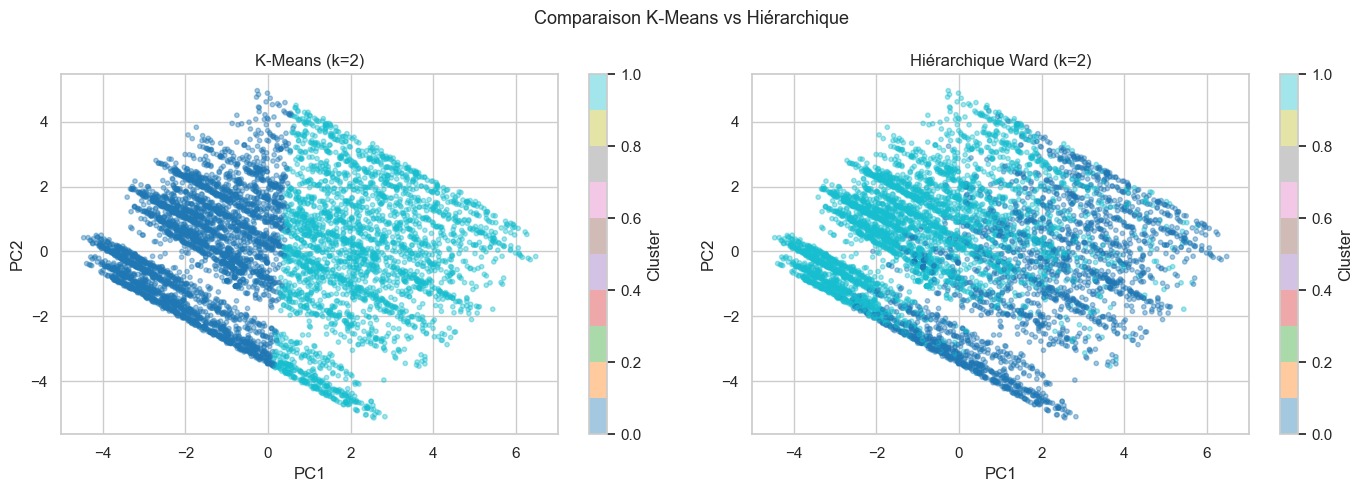

In [53]:
# Visualisation côte à côte K-Means vs Hiérarchique
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, labels, title in zip(axes,
                              [km_labels, hc_labels],
                              [f'K-Means (k={best_k})', f'Hiérarchique Ward (k={best_k})']):
    scatter = ax.scatter(X_cluster[:,0], X_cluster[:,1], c=labels,
                         cmap='tab10', alpha=0.4, s=10)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_title(title)
    plt.colorbar(scatter, ax=ax, label='Cluster')

plt.suptitle('Comparaison K-Means vs Hiérarchique', fontsize=13)
plt.tight_layout()
plt.show()

---
## ✅ Résumé Final du Pipeline

### Prétraitement
| Étape | Action | Résultat |
|---|---|---|
| Valeurs sentinelles | -99 → NaN | Données corrompues nettoyées |
| Doublons | drop_duplicates() | 0 doublon supprimé |
| Valeurs manquantes | Médiane (num.) / Mode (cat.) | 0 valeur manquante |
| Outliers | Écrêtage IQR (capping) | Valeurs extrêmes bornées |
| Encodage | LabelEncoder | Variables catégorielles encodées |
| Normalisation | Min-Max sur numériques | Plage [0, 1] |
| Split | 70/30 et 80/20 avec stratify | Sans data leakage |
| Standardisation | Z-score (fit sur train seul) | μ=0, σ=1 |
| PCA | 80% variance | Réduction dimensionnelle |

### Classification
| Modèle | Évaluation |
|---|---|
| Logistic Regression | CV 5-fold |
| KNN | CV 5-fold + GridSearchCV |
| Decision Tree | CV 5-fold + GridSearchCV |
| Random Forest | CV 5-fold + GridSearchCV |
| SVM (RBF) | CV 5-fold |
| Gradient Boosting | CV 5-fold |

### Clustering
| Algorithme | Métriques |
|---|---|
| K-Means | Coude + Silhouette + Davies-Bouldin + CH |
| DBSCAN | Exploration eps/min_samples |
| Hiérarchique (Ward) | Dendrogramme + métriques |

In [54]:
print('=== RÉSUMÉ FINAL ===')
print(f'  Dataset               : {df.shape[0]} individus × {df.shape[1]} variables')
print(f'  Après prétraitement   : {X_cluster.shape[0]} individus × {X_cluster.shape[1]} composantes')
print()
print('=== CLASSIFICATION (Test Accuracy) ===')
print(results_df[['Modèle','Test Accuracy']].sort_values('Test Accuracy', ascending=False).to_string(index=False))
print()
print('=== GRIDSEARCHCV (Test Accuracy) ===')
print(gs_results[['Modèle','Test Accuracy','Best CV Accuracy']].to_string(index=False))
print()
print(f'=== CLUSTERING ===')
print(comparison[['Algorithme','Silhouette (↑)','Davies-Bouldin (↓)','N clusters']].to_string(index=False))

=== RÉSUMÉ FINAL ===
  Dataset               : 6708 individus × 25 variables
  Après prétraitement   : 6708 individus × 10 composantes

=== CLASSIFICATION (Test Accuracy) ===
             Modèle  Test Accuracy
Logistic Regression         0.9707
          SVM (RBF)         0.9677
  Gradient Boosting         0.9608
      Random Forest         0.9593
      Decision Tree         0.9354
          KNN (k=5)         0.9349

=== GRIDSEARCHCV (Test Accuracy) ===
                    Modèle  Test Accuracy  Best CV Accuracy
          KNN (GridSearch)         0.9503            0.9404
Decision Tree (GridSearch)         0.9394            0.9387
Random Forest (GridSearch)         0.9622            0.9517

=== CLUSTERING ===
             Algorithme  Silhouette (↑)  Davies-Bouldin (↓)  N clusters
          K-Means (k=2)          0.2036              1.8742           2
       DBSCAN (eps=0.3)          1.0000              0.0000           3
Hiérarchique Ward (k=2)          0.1322              2.4054       